In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.


# Inicializar Drive e Baixar os Dados (**WARNING**: necessário fazer apenas uma vez)

In [ ]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# drive_path = '/content/drive/MyDrive/PSD-Trabalho'

# if not os.path.exists(drive_path):
#     os.makedirs(drive_path)
#     print(f"Pasta criada em: {drive_path}")
# else:
#     print(f"A pasta já existe em: {drive_path}")

In [ ]:
# import wfdb
# wfdb.dl_database('mitdb', dl_dir=drive_path)

# Análise Exploratória

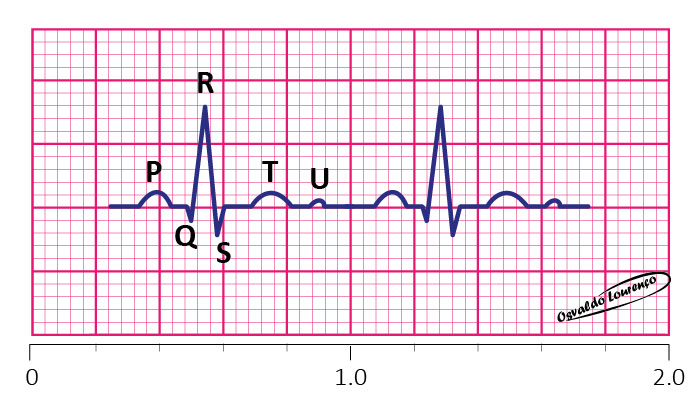

- Onda P: Representa a despolarização atrial, ou seja, a contração dos átrios.
- Complexo QRS: Representa a despolarização ventricular, ou seja, a contração dos ventrículos. É a onda mais proeminente e indica a atividade elétrica mais forte do coração.
- Onda T: Representa a repolarização ventricular, ou seja, o relaxamento dos ventrículos após a contração. Este é um processo crucial para preparar o coração para o próximo batimento.

In [ ]:
import wfdb
from google.colab import drive
import os

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/PSD-Trabalho'

if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"Pasta criada em: {drive_path}")
else:
    print(f"A pasta já existe em: {drive_path}")

Mounted at /content/drive
A pasta já existe em: /content/drive/MyDrive/PSD-Trabalho


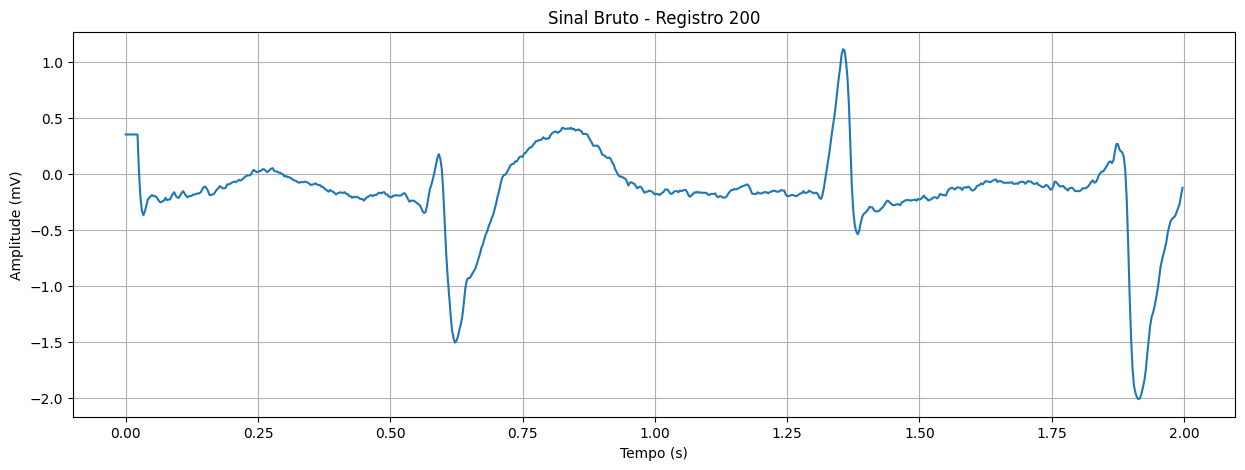

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

record = wfdb.rdrecord(os.path.join(drive_path, '200'))

signal = record.p_signal[:, 0]
fs = record.fs
tempo = np.arange(len(signal)) / fs

plt.figure(figsize=(15, 5))
plt.plot(tempo[:fs*2], signal[:fs*2])
plt.title(f"Sinal Bruto - Registro {record.record_name}")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

#Tipos de Ruído (WARNING: Daqui para baixo é gptasso, não sei o que aconteceu)

[Artigo Detection and classification of ECG noises using decomposition on mixed codebook for quality analysis
](https://pmc.ncbi.nlm.nih.gov/articles/PMC7067057/
)

Neste artigo acima são destacados quatro tipos de rúido do ECG:
- baseline wander (BW)
- muscle artefact (MA)
- power line interference (PLI)
- additive white Gaussian noise (AWGN)

In [ ]:
from scipy.signal import butter, filtfilt, welch
from scipy.stats import kurtosis, skew

def detectar_baseline_wander(signal, fs):
    # Filtro passa-alta para isolar componente de baixa frequência
    b, a = butter(4, 0.5 / (fs / 2), btype='high')
    signal_filtrado = filtfilt(b, a, signal)

    # Ruído de baseline = diferença entre sinal original e filtrado
    baseline = signal - signal_filtrado

    # Métrica: desvio padrão do componente de baixa frequência
    baseline_std = np.std(baseline)
    threshold = 0.1  # mV — ajustar conforme necessidade

    return {
        'baseline': baseline,
        'std': baseline_std,
        'detectado': baseline_std > threshold
    }

In [ ]:
def detectar_ruido_alta_freq(signal, fs):
    # Isola componente de alta frequência (> 100 Hz)
    b, a = butter(4, 100 / (fs / 2), btype='high')
    hf_component = filtfilt(b, a, signal)

    # Métricas de ruído de alta frequência
    hf_power = np.var(hf_component)
    total_power = np.var(signal)
    snr = 10 * np.log10((total_power - hf_power) / hf_power) if hf_power > 0 else np.inf

    return {
        'hf_power': hf_power,
        'snr_db': snr,
        'detectado': snr < 20  # SNR abaixo de 20 dB indica ruído significativo
    }

In [ ]:
def detectar_ruido_powerline(signal, fs, freq_rede=60):
    freqs, psd = welch(signal, fs, nperseg=1024)

    # Potência na frequência da rede
    idx_powerline = np.argmin(np.abs(freqs - freq_rede))
    potencia_60hz = psd[idx_powerline]

    # Potência média do espectro (excluindo banda da rede)
    mask = (freqs < freq_rede - 2) | (freqs > freq_rede + 2)
    potencia_media = np.mean(psd[mask])

    razao = potencia_60hz / potencia_media

    return {
        'potencia_60hz': potencia_60hz,
        'razao': razao,
        'detectado': razao > 10  # Pico de 60 Hz 10x acima do espectro médio
    }

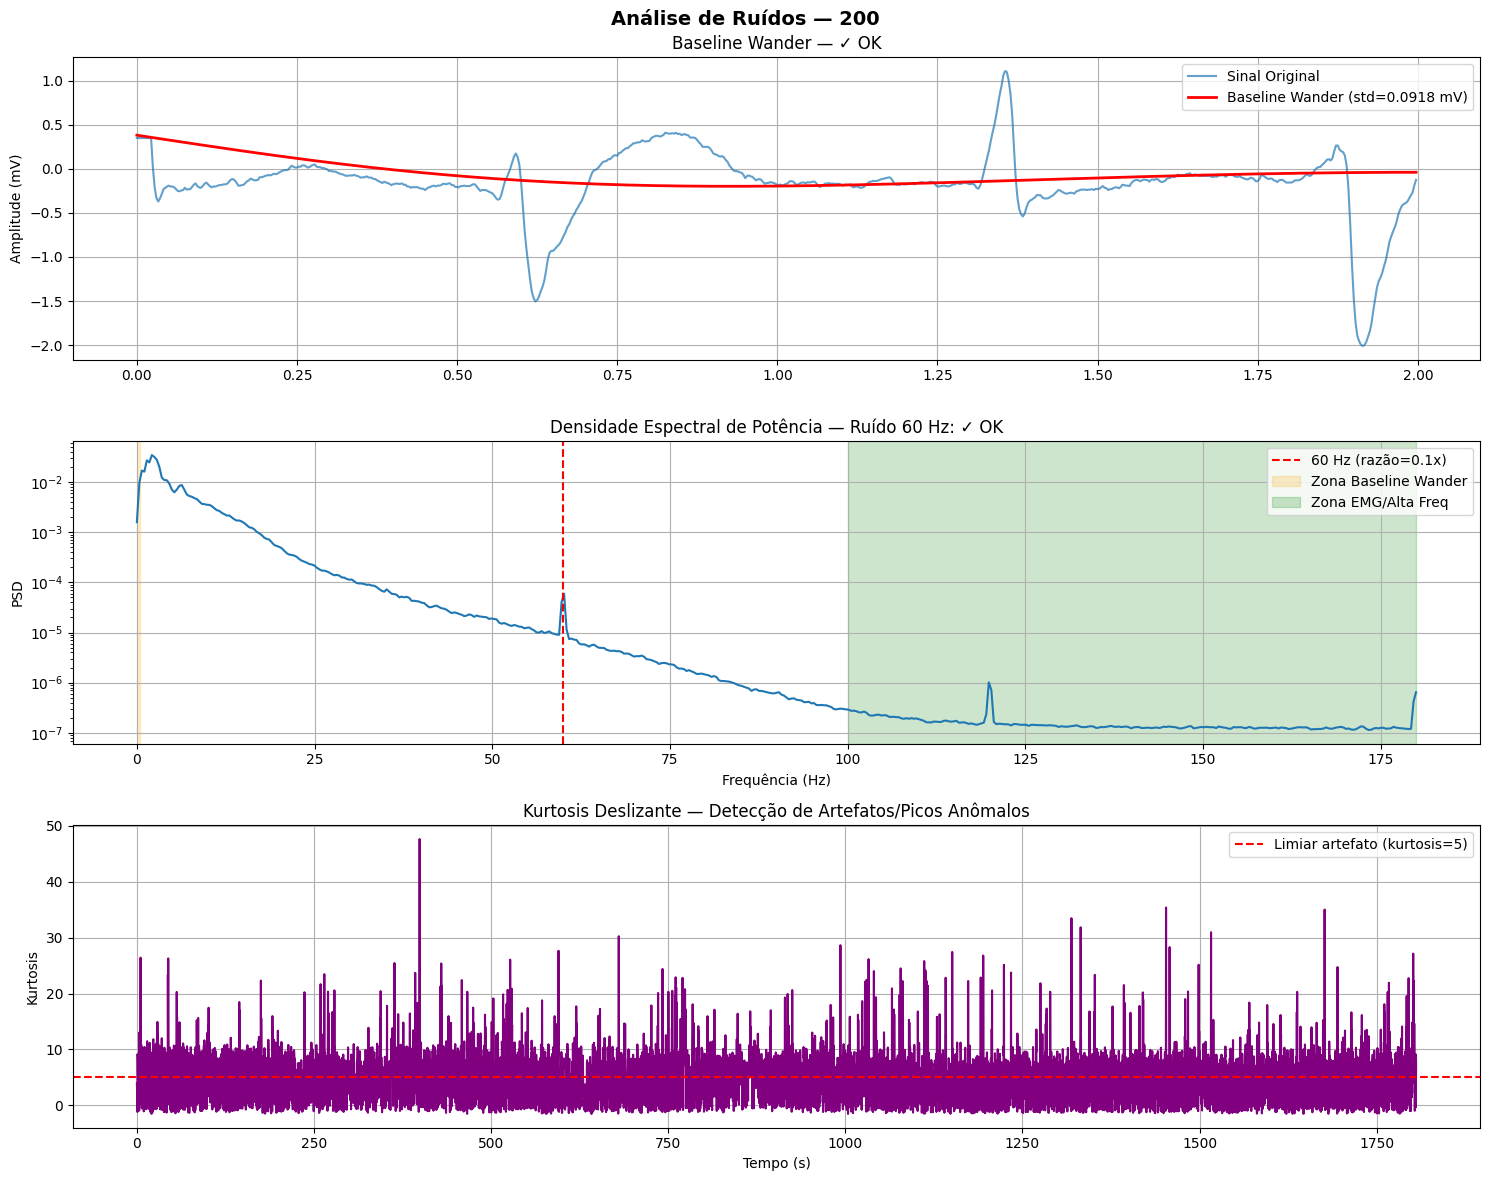


===== RELATÓRIO DE RUÍDOS =====
  Baseline Wander : ✓ OK (std=0.0918 mV)
  Ruído 60 Hz     : ✓ OK (razão=0.1x)
  Ruído Alta Freq : ✓ OK (SNR=41.0 dB)


In [ ]:
def analisar_ruidos_ecg(signal, fs, nome_registro=""):
    tempo = np.arange(len(signal)) / fs
    freqs, psd = welch(signal, fs, nperseg=1024)

    # Detectar cada tipo de ruído
    r_baseline  = detectar_baseline_wander(signal, fs)
    r_alta_freq = detectar_ruido_alta_freq(signal, fs)
    r_powerline = detectar_ruido_powerline(signal, fs)

    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    fig.suptitle(f"Análise de Ruídos — {nome_registro}", fontsize=14, fontweight='bold')

    # --- Plot 1: Sinal + Baseline ---
    axes[0].plot(tempo[:fs*2], signal[:fs*2], label='Sinal Original', alpha=0.7)
    axes[0].plot(tempo[:fs*2], r_baseline['baseline'][:fs*2],
                 label=f"Baseline Wander (std={r_baseline['std']:.4f} mV)",
                 color='red', linewidth=2)
    status = "⚠ DETECTADO" if r_baseline['detectado'] else "✓ OK"
    axes[0].set_title(f"Baseline Wander — {status}")
    axes[0].set_ylabel("Amplitude (mV)")
    axes[0].legend(); axes[0].grid(True)

    # --- Plot 2: Espectro de Frequência ---
    axes[1].semilogy(freqs, psd)
    axes[1].axvline(x=60, color='red', linestyle='--',
                    label=f"60 Hz (razão={r_powerline['razao']:.1f}x)")
    axes[1].axvspan(0, 0.5, alpha=0.2, color='orange', label='Zona Baseline Wander')
    axes[1].axvspan(100, fs/2, alpha=0.2, color='green', label='Zona EMG/Alta Freq')
    status_pl = "⚠ DETECTADO" if r_powerline['detectado'] else "✓ OK"
    axes[1].set_title(f"Densidade Espectral de Potência — Ruído 60 Hz: {status_pl}")
    axes[1].set_xlabel("Frequência (Hz)"); axes[1].set_ylabel("PSD")
    axes[1].legend(); axes[1].grid(True)

    # --- Plot 3: Kurtosis deslizante (detecta artefatos) ---
    janela = int(fs * 0.5)  # janela de 0.5s
    kurt_vals = [
        kurtosis(signal[i:i+janela])
        for i in range(0, len(signal) - janela, janela // 2)
    ]
    t_kurt = np.linspace(0, len(signal)/fs, len(kurt_vals))
    axes[2].plot(t_kurt, kurt_vals, color='purple')
    axes[2].axhline(y=5, color='red', linestyle='--', label='Limiar artefato (kurtosis=5)')
    axes[2].fill_between(t_kurt, 5, kurt_vals,
                          where=np.array(kurt_vals) > 5, alpha=0.3, color='red')
    axes[2].set_title("Kurtosis Deslizante — Detecção de Artefatos/Picos Anômalos")
    axes[2].set_xlabel("Tempo (s)"); axes[2].set_ylabel("Kurtosis")
    axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    # Resumo
    print("\n===== RELATÓRIO DE RUÍDOS =====")
    print(f"  Baseline Wander : {'⚠ DETECTADO' if r_baseline['detectado'] else '✓ OK'} (std={r_baseline['std']:.4f} mV)")
    print(f"  Ruído 60 Hz     : {'⚠ DETECTADO' if r_powerline['detectado'] else '✓ OK'} (razão={r_powerline['razao']:.1f}x)")
    print(f"  Ruído Alta Freq : {'⚠ DETECTADO' if r_alta_freq['detectado'] else '✓ OK'} (SNR={r_alta_freq['snr_db']:.1f} dB)")
    print("================================")

# Executar
analisar_ruidos_ecg(signal, fs, record.record_name)

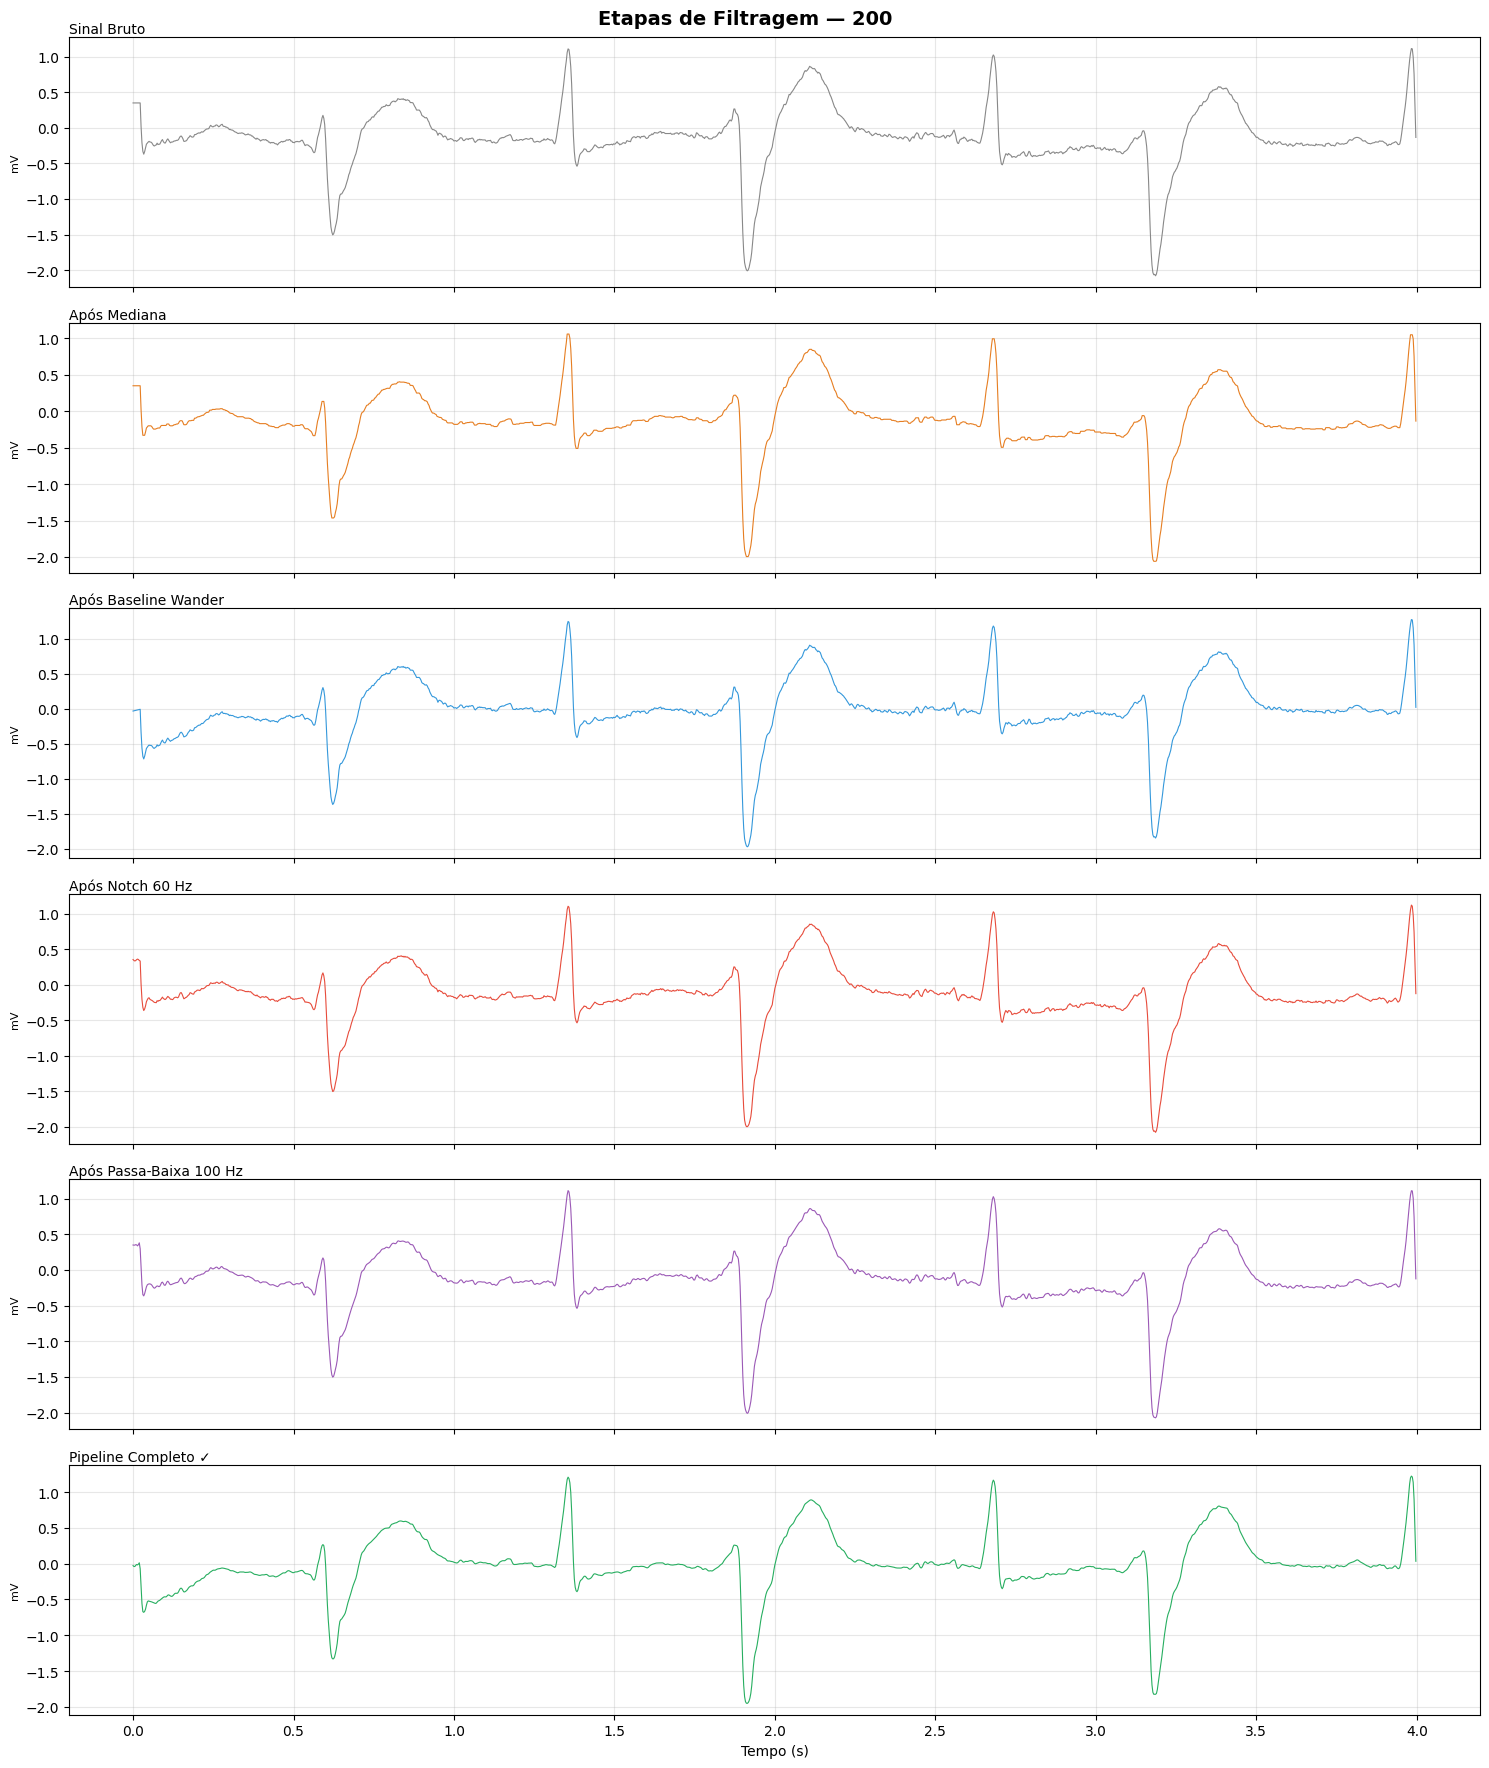

In [ ]:
from scipy.signal import butter, filtfilt, iirnotch, medfilt
import numpy as np

# ─────────────────────────────────────────
# 1. BASELINE WANDER — Filtro Passa-Alta
# Remove deriva lenta de baixa frequência (< 0.5 Hz)
# ─────────────────────────────────────────
def filtro_baseline_wander(signal, fs, cutoff=0.5):
    b, a = butter(4, cutoff / (fs / 2), btype='high')
    return filtfilt(b, a, signal)


# ─────────────────────────────────────────
# 2. RUÍDO 60 Hz — Filtro Notch
# Remove interferência da rede elétrica (60 Hz no Brasil)
# ─────────────────────────────────────────
def filtro_notch_60hz(signal, fs, freq=60.0, Q=30.0):
    b, a = iirnotch(freq / (fs / 2), Q)
    return filtfilt(b, a, signal)


# ─────────────────────────────────────────
# 3. RUÍDO EMG / ALTA FREQUÊNCIA — Filtro Passa-Baixa
# Remove ruído muscular e de eletrodo (> 100 Hz)
# ─────────────────────────────────────────
def filtro_alta_frequencia(signal, fs, cutoff=100.0):
    b, a = butter(4, cutoff / (fs / 2), btype='low')
    return filtfilt(b, a, signal)


# ─────────────────────────────────────────
# 4. ARTEFATOS / PICOS — Filtro de Mediana
# Remove picos abruptos preservando morfologia do QRS
# ─────────────────────────────────────────
def filtro_mediana(signal, kernel_size=5):
    # kernel_size deve ser ímpar
    return medfilt(signal, kernel_size=kernel_size)


# ─────────────────────────────────────────
# PIPELINE COMPLETO — aplica todos os filtros em sequência
# ─────────────────────────────────────────
def pipeline_filtragem(signal, fs):
    s = filtro_mediana(signal, kernel_size=5)         # 1. Remove artefatos pontuais
    s = filtro_baseline_wander(s, fs, cutoff=0.5)     # 2. Remove deriva de baseline
    s = filtro_notch_60hz(s, fs, freq=60.0, Q=30.0)  # 3. Remove 60 Hz
    s = filtro_alta_frequencia(s, fs, cutoff=100.0)   # 4. Remove EMG
    return s


# ─────────────────────────────────────────
# VISUALIZAÇÃO: Antes x Depois
# ─────────────────────────────────────────
def comparar_filtros(signal, fs, nome_registro=""):
    tempo = np.arange(len(signal)) / fs
    janela = slice(0, fs * 4)  # primeiros 4 segundos

    etapas = [
        ("Sinal Bruto",              signal),
        ("Após Mediana",             filtro_mediana(signal)),
        ("Após Baseline Wander",     filtro_baseline_wander(signal, fs)),
        ("Após Notch 60 Hz",         filtro_notch_60hz(signal, fs)),
        ("Após Passa-Baixa 100 Hz",  filtro_alta_frequencia(signal, fs)),
        ("Pipeline Completo ✓",      pipeline_filtragem(signal, fs)),
    ]

    fig, axes = plt.subplots(len(etapas), 1, figsize=(15, 18), sharex=True)
    fig.suptitle(f"Etapas de Filtragem — {nome_registro}", fontsize=14, fontweight='bold')

    cores = ['#888888', '#e67e22', '#3498db', '#e74c3c', '#9b59b6', '#27ae60']

    for ax, (titulo, s), cor in zip(axes, etapas, cores):
        ax.plot(tempo[janela], s[janela], color=cor, linewidth=0.8)
        ax.set_title(titulo, fontsize=10, loc='left', pad=3)
        ax.set_ylabel("mV", fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Tempo (s)")
    plt.tight_layout()
    plt.show()

    return pipeline_filtragem(signal, fs)


# Executar
signal_filtrado = comparar_filtros(signal, fs, record.record_name)